# BERTopic — hierarchy-based soft clustering (scales to 100k)

`1.1` got soft weights from HDBSCAN's `calculate_probabilities=True`, which is slow and
memory-heavy, so it only ran on 10k docs. The heaviness, though, is **specific to
HDBSCAN's algorithm** (`all_points_membership_vectors`), *not* to soft clustering in
general — we're just working with vectors.

Here we build a **genuine hierarchy** and read soft weights off it, cheaply, on the full
**100k-doc** corpus. The key trick: cluster the **~1,400 topics** into a dendrogram (a
1,400² linkage — milliseconds), *not* the 100k documents.

> ⚠️ **Why not a dendrogram over the documents directly?** Agglomerative clustering
> needs an O(n²) distance matrix — at 100k docs that's **~80 GB**. That's the single
> heaviest thing you could do here. The output weight matrix is also a floor: `n×k`
> floats ≈ 1.15 GB at 100k×1439 in float64 → we keep cuts small and store **float32**.

**Recipe:** fit topics → linkage over topic-centroid embeddings → cut at `K`
super-themes → soft weight of each doc = `softmax(cosine(doc, super-centroid))`.
One matmul, batchable, tens of MB.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.special import softmax

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PER_YEAR = 10000  # full 100k-doc corpus — the hierarchy math is cheap regardless
SAMPLE_PATH = PROJECT_ROOT / "data" / "processed" / f"sample_{PER_YEAR}_per_year.parquet"

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
RANDOM_SEED = 42

CUT_LEVELS = [10, 25, 50]  # dendrogram cuts → # of super-themes
PRIMARY_K = 25             # the cut we save in detail
TEMP = 0.1                 # softmax temperature on cosine sims (smaller = sharper)

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("device:", DEVICE)

device: mps


## 1. Load sample & embed

Same 100k corpus as `1.0`. Build it first if missing:

```bash
uv run python scripts/build_sample.py --per-year 10000
```

In [2]:
assert SAMPLE_PATH.exists(), (
    f"{SAMPLE_PATH} missing — run: uv run python scripts/build_sample.py --per-year {PER_YEAR}"
)

corpus = pd.read_parquet(SAMPLE_PATH).drop_duplicates(subset="Headline").reset_index(drop=True)
docs = corpus["Headline"].tolist()

embedder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
embeddings = np.asarray(embedder.encode(docs, batch_size=64, show_progress_bar=True), dtype="float32")
print(f"{len(docs):,} docs, embeddings {embeddings.shape} {embeddings.dtype}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1562 [00:00<?, ?it/s]

99,950 docs, embeddings (99950, 384) float32


## 2. Fit base topics (offline)

Same config as `1.0` — this is the only expensive step (~9 min, ~1.5 GB on 100k). We do
**not** need `calculate_probabilities`; the soft weights come later from the hierarchy.
After fitting, `topic_model.topic_embeddings_` holds one centroid vector per topic.

In [3]:
topic_model = BERTopic(
    embedding_model=embedder,
    umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_SEED),
    hdbscan_model=HDBSCAN(min_cluster_size=10, min_samples=5, metric="euclidean",
                          cluster_selection_method="eom", prediction_data=True),
    vectorizer_model=CountVectorizer(stop_words="english", ngram_range=(1, 2)),
    verbose=True,
)
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
topics = np.asarray(topics)

info = topic_model.get_topic_info()
n_topics = int((info["Topic"] != -1).sum())
print(f"{n_topics} base topics + outliers; topic_embeddings_ {np.asarray(topic_model.topic_embeddings_).shape}")

2026-06-22 17:09:07,586 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-06-22 17:10:35,827 - BERTopic - Dimensionality - Completed ✓


2026-06-22 17:10:35,843 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-06-22 17:10:41,718 - BERTopic - Cluster - Completed ✓


2026-06-22 17:10:41,777 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-22 17:10:44,550 - BERTopic - Representation - Completed ✓


1439 base topics + outliers; topic_embeddings_ (1440, 384)


## 3. Build the topic dendrogram

`topic_embeddings_` is row-aligned with the **sorted** topic ids (topic `-1` first). We
drop `-1` and run a **ward** `linkage` over the remaining ~1,400 topic centroids (on
L2-normalized vectors, so it's cosine geometry but with *balanced* clusters — average/
single linkage chains into one giant blob in high-dim embedding space). The same
`linkage_function` is handed to BERTopic's `hierarchical_topics` / `visualize_hierarchy`,
so the picture and the soft-weight math use *one* consistent hierarchy.

In [4]:
topic_ids = sorted(info["Topic"])                       # [-1, 0, 1, ...]
te = np.asarray(topic_model.topic_embeddings_)          # aligned with topic_ids
real_rows = [i for i, t in enumerate(topic_ids) if t != -1]
real_ids = [topic_ids[i] for i in real_rows]
te_real = te[real_rows]
sizes = info.set_index("Topic")["Count"]

def topic_linkage(x):
    # ward gives *balanced* clusters (average/single linkage chains into one giant blob in
    # high-dim embedding space). Handle both call conventions: we pass 2-D topic vectors
    # (-> ward on L2-normalized = cosine geometry); BERTopic's viz passes a 1-D condensed
    # distance matrix (-> feed straight to ward).
    x = np.asarray(x)
    if x.ndim == 1:
        return linkage(x, method="ward")
    return linkage(normalize(x), method="ward", metric="euclidean")

Z = topic_linkage(te_real)
print(f"linkage over {len(real_ids)} topic centroids -> Z {Z.shape}")

linkage over 1439 topic centroids -> Z (1438, 4)


### Hover-rich names for every internal node

BERTopic draws an internal node's hover label from `hier_df['Parent_Name']`. By default
that's a stopword-heavy underscore string; we **overwrite it** with the *pooled top
words* of the topics beneath the node plus its size (`N topics, M docs`). Now hovering
any merge point answers "what cluster would form if I cut here?".

In [5]:
hier_df = topic_model.hierarchical_topics(docs, use_ctfidf=False, linkage_function=topic_linkage)

def clean_name(topic_list):
    # pooled top c-TF-IDF words across the topics under a node, + cluster size
    pool = {}
    for tid in topic_list:
        for w, sc in topic_model.get_topic(tid)[:5]:
            if w:
                pool[w] = pool.get(w, 0.0) + sc
    top = sorted(pool, key=pool.get, reverse=True)[:6]
    ndocs = int(sizes.reindex(topic_list).fillna(0).sum())
    return f"{' · '.join(top)}  ({len(topic_list)} topics, {ndocs:,} docs)"

hier_df["Parent_Name"] = hier_df["Topics"].apply(clean_name)

# Inline preview: cap leaves so it's readable in the notebook. Hover the merge points.
fig_hier = topic_model.visualize_hierarchy(
    hierarchical_topics=hier_df, use_ctfidf=False, linkage_function=topic_linkage,
    top_n_topics=80,
)
fig_hier

  0%|          | 0/1438 [00:00<?, ?it/s]

  2%|▏         | 25/1438 [00:00<00:05, 248.01it/s]

  4%|▎         | 53/1438 [00:00<00:05, 263.07it/s]

  6%|▌         | 81/1438 [00:00<00:05, 270.02it/s]

  8%|▊         | 110/1438 [00:00<00:04, 275.09it/s]

...

 95%|█████████▍| 1360/1438 [00:05<00:00, 223.92it/s]

 96%|█████████▌| 1383/1438 [00:05<00:00, 219.13it/s]

 98%|█████████▊| 1405/1438 [00:05<00:00, 210.65it/s]

 99%|█████████▉| 1427/1438 [00:05<00:00, 194.49it/s]

100%|██████████| 1438/1438 [00:05<00:00, 247.52it/s]

### A prettier view: nested theme icicle

A 1,400-leaf dendrogram is hard to read. The same hierarchy is far nicer as a **nested
icicle**: cut the tree at a few resolutions (coarse → fine), nest them (cuts of one
linkage are always nested), size each block by article count, colour by coarse theme,
and label with pooled top words. **Click any block to zoom in; hover for the full name.**

In [6]:
import plotly.graph_objects as go
import plotly.colors as pc

K_LEVELS_VIZ = [k for k in (8, 25, 60) if k < len(real_ids)]   # coarse -> fine
lev = {K: fcluster(Z, t=K, criterion="maxclust") for K in K_LEVELS_VIZ}

def words_for(members, n=5):
    pool = {}
    for tid in members:
        for w, sc in topic_model.get_topic(tid)[:5]:
            if w:
                pool[w] = pool.get(w, 0.0) + sc
    return sorted(pool, key=pool.get, reverse=True)[:n]

# Build nested nodes: ROOT -> coarse -> mid -> fine, members accumulated bottom-up.
nodes = {}
def add(nid, parent, coarse, members):
    nd = nodes.setdefault(nid, {"parent": parent, "coarse": coarse, "members": set()})
    nd["members"].update(members)

for idx, tid in enumerate(real_ids):
    coarse = int(lev[K_LEVELS_VIZ[0]][idx])
    path = ["ROOT"]
    for K in K_LEVELS_VIZ:
        path.append(path[-1] + f"|K{K}:{lev[K][idx]}")
    for d in range(1, len(path)):
        add(path[d], path[d - 1], coarse, [tid])   # parent of the coarse level is "ROOT"
add("ROOT", "", -1, real_ids)

palette = pc.qualitative.Set3 + pc.qualitative.Pastel1 + pc.qualitative.Pastel2
ids, labels, parents, values, hover, colors = [], [], [], [], [], []
for nid, nd in nodes.items():
    mem = list(nd["members"])
    val = int(sizes.reindex(mem).fillna(0).sum())
    ids.append(nid); parents.append(nd["parent"]); values.append(val)
    labels.append("ALL THEMES" if nid == "ROOT" else " · ".join(words_for(mem, 3)))
    hover.append(f"<b>{' · '.join(words_for(mem, 6))}</b><br>{len(mem)} topics · {val:,} docs")
    colors.append("#efefef" if nid == "ROOT" else palette[nd["coarse"] % len(palette)])

fig_ice = go.Figure(go.Icicle(
    ids=ids, labels=labels, parents=parents, values=values, branchvalues="total",
    customdata=hover, hovertemplate="%{customdata}<extra></extra>",
    marker=dict(colors=colors, line=dict(color="white", width=1)),
    tiling=dict(orientation="h"), sort=True,
))
fig_ice.update_layout(
    margin=dict(t=46, l=8, r=8, b=8), height=720, width=1150,
    title="Bloomberg theme hierarchy  ·  click a block to zoom, hover for the cluster name",
    font=dict(size=12),
)
print(f"icicle: {len(ids)} nodes over levels {K_LEVELS_VIZ}")
fig_ice

icicle: 94 nodes over levels [8, 25, 60]


## 4. Cut the tree → super-themes

`fcluster(..., 'maxclust')` cuts the dendrogram into `K` groups. Each super-theme's
embedding is the **size-weighted mean** of its member topic centroids (bigger topics
pull harder), and its keywords are pooled from the member topics' top c-TF-IDF words.

In [7]:
def build_supers(K):
    # returns (tid->super, super_centroids[K,d], super_keywords[K])
    lab = fcluster(Z, t=K, criterion="maxclust") - 1            # 0..K-1 per real topic
    tid_to_super = {tid: int(s) for tid, s in zip(real_ids, lab)}

    cent = np.zeros((K, te_real.shape[1]), dtype="float32")
    for ridx, tid in enumerate(real_ids):
        cent[tid_to_super[tid]] += te_real[ridx] * float(sizes[tid])
    cent = normalize(cent)

    words = []
    for s in range(K):
        members = [tid for tid in real_ids if tid_to_super[tid] == s]
        pool = {}
        for tid in members:
            for w, sc in topic_model.get_topic(tid)[:5]:
                pool[w] = pool.get(w, 0.0) + sc
        top = sorted(pool, key=pool.get, reverse=True)[:8]
        words.append(", ".join(top))
    return tid_to_super, cent, words

tid_to_super, super_cent, super_words = build_supers(PRIMARY_K)
print(f"K={PRIMARY_K} super-themes:")
for s, w in enumerate(super_words):
    n = sum(v == s for v in tid_to_super.values())
    print(f"  S{s:2d} ({n:2d} topics): {w}")

K=25 super-themes:
  S 0 (20 topics): certificate, reg 39, loss certificate, dp regulations, exch announcement, 39 details, sebi dp, certificate reg
  S 1 (39 topics): opportunities, pst nse, 00 pst, rbi, tata, pst, joshimath, nse india
  S 2 (59 topics): yuan, lng, fxcm, flash crash, eurusd, treasuries, softbank, coinbase
  S 3 (44 topics): stocks page, page, simply wall, hedge, simply, rsrch, schaeffers, schaeffers rsrch
  S 4 (180 topics): advantage, trading advice, advantage moves, trading signals, proactive strategies, advice, proactive, listen
  S 5 (39 topics): rate fix, frn variable, variable rate, bancorp, dealers borrow, securities fed, student loan, river bancorp
  S 6 (137 topics): jpmorgan chase, sc 13g, chase, chase sc, baystreet ca, baystreet, surrenders, insider buying
  S 7 (60 topics): proposals jan, proposals, speaker, elizabeth, florida sba, sba backs, shutdown, sba
  S 8 (59 topics): vringo, scrushy, arcelormittal, ftx, crowdfundinsider, ransomware, patent, firearm

## 5. Soft per-document weights

The whole point: `softmax(cosine(doc, super-centroid) / TEMP)` → a `(n_docs × K)` matrix
where every row is a probability distribution over the `K` super-themes. One matmul,
float32, ~10 MB. Every doc gets weights — including the HDBSCAN outliers (topic `-1`),
which simply end up with a flatter distribution.

In [8]:
sims = normalize(embeddings) @ super_cent.T          # (n_docs, K) cosine
W = softmax(sims / TEMP, axis=1).astype("float32")
print(f"W {W.shape} {W.dtype}  rows sum~1: {np.allclose(W.sum(1), 1, atol=1e-4)}  ~{W.nbytes/1e6:.0f} MB")

def top_supers(i, n=3):
    order = np.argsort(W[i])[::-1][:n]
    return ", ".join(f"S{s}={W[i, s]:.2f}" for s in order)

# Most ambiguous headlines (highest 2nd-best super-theme weight).
second = np.sort(W, axis=1)[:, -2]
amb = pd.DataFrame({
    "headline": [d[:70] for d in docs],
    "hard_topic": topics,
    "top_super_themes": [top_supers(i) for i in range(len(docs))],
    "second_weight": second.round(3),
}).sort_values("second_weight", ascending=False)
amb.head(12)

W (99950, 25) float32  rows sum~1: True  ~10 MB


,headline,hard_topic,top_super_themes,second_weight
87326,The Bulwark: Republican Former Members of Cong...,1417,"S7=0.44, S8=0.37, S18=0.03",0.371
42616,"Algemeiner: Greece, Israel and Cyprus Call Tur...",-1,"S18=0.42, S17=0.36, S20=0.03",0.362
66603,Middle East 24: Hosni Abidi: Ukraine’s entry i...,-1,"S18=0.39, S17=0.35, S20=0.03",0.351
27318,McClatchy DC: GOP senators target dossier auth...,831,"S7=0.40, S8=0.35, S11=0.03",0.349
59164,FDA: 2020: A Strong Year for New Drug Therapy ...,12,"S12=0.38, S13=0.35, S23=0.03",0.349
66159,100% Recovery-GoldenBiotech Announces Topline ...,1117,"S13=0.40, S12=0.35, S23=0.03",0.346
61510,Bailey Jerome Ronnell: 3 2021/12/21,0,"S21=0.37, S9=0.35, S7=0.04",0.346
31911,Dallas David D: 4/A 2018/12/21,0,"S21=0.38, S9=0.34, S6=0.02",0.344
82034,"Amazon, Snap, Others Discuss New AI Devices",-1,"S15=0.41, S14=0.34, S24=0.03",0.344
2260,U.S. Concerned About Iran-Saudi Tensions: Kirby,199,"S18=0.35, S17=0.34, S16=0.06",0.341


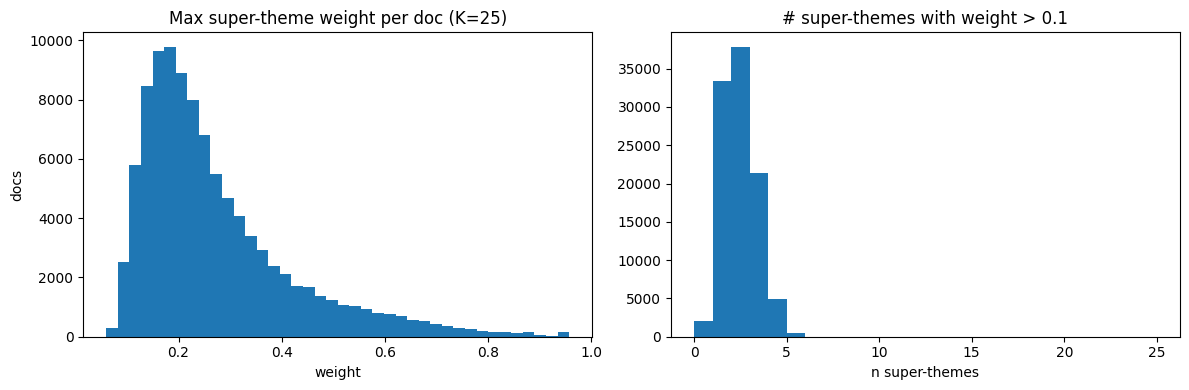

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(W.max(axis=1), bins=40)
ax[0].set(title=f"Max super-theme weight per doc (K={PRIMARY_K})", xlabel="weight", ylabel="docs")
ax[1].hist((W > 0.1).sum(axis=1), bins=range(0, PRIMARY_K + 1))
ax[1].set(title="# super-themes with weight > 0.1", xlabel="n super-themes")
plt.tight_layout()

## 6. Multi-resolution view

Because it's so cheap, we can read weights at several cuts at once — a coarse→fine soft
profile per document. Here: the dominant super-theme each doc lands in at each `K`.

In [10]:
multi = {"headline": [d[:60] for d in docs]}
for K in CUT_LEVELS:
    _, cent_k, _ = build_supers(K)
    Wk = softmax((normalize(embeddings) @ cent_k.T) / TEMP, axis=1)
    multi[f"top_super@K{K}"] = Wk.argmax(1)
    multi[f"conf@K{K}"] = Wk.max(1).round(2)
pd.DataFrame(multi).head(10)

,headline,top_super@K10,conf@K10,top_super@K25,conf@K25,top_super@K50,conf@K50
0,EON: E.ON UK availability update - 31/12/2015,6,0.23,15,0.14,30,0.08
1,ProactivInvst UK: Gold heads into New Year wit...,5,0.38,13,0.16,26,0.10
2,Mbac Fertilizer: MBAC Provides Update on Its S...,8,0.41,19,0.24,39,0.17
3,Centamin Plc: 21 Mar 2016 Annual results for t...,2,0.23,6,0.14,10,0.13
4,Provident Fin: 2016 Q1 interim management stat...,2,0.33,6,0.19,4,0.11
5,Imperial Tobacco: 8 November 2016 - Preliminar...,9,0.23,23,0.35,46,0.21
6,"Elexon Ltd: HEYM27 Special Information, 2016-0...",2,0.35,6,0.24,10,0.20
7,"Elexon Ltd: HEYM27 Special Information, 2016-0...",2,0.32,6,0.22,10,0.20
8,Ft Worth Star: Weekend TV/Radio listings for D...,4,0.76,9,0.38,22,0.20
9,"Seeking Alpha: NTAP, FEYE, SPLK, others make F...",6,0.28,15,0.20,30,0.13


## 7. Save the soft assignments

In [11]:
OUT = PROJECT_ROOT / "data" / "processed" / f"hier_soft_{PER_YEAR}_per_year_K{PRIMARY_K}.parquet"
soft_df = pd.concat([
    corpus[["Headline", "CaptureTime", "year"]].reset_index(drop=True),
    pd.Series(W.argmax(1), name=f"super_{PRIMARY_K}"),
    pd.DataFrame(W, columns=[f"super_{s}" for s in range(PRIMARY_K)]),
], axis=1)
soft_df.to_parquet(OUT, index=False)
print(f"wrote {soft_df.shape} -> {OUT.relative_to(PROJECT_ROOT)}")

# Export the FULL hover-rich dendrogram as standalone HTML (viewable without Jupyter).
# Height scales with #topics so every leaf/merge is reachable; hover any node for its name.
fig_full = topic_model.visualize_hierarchy(
    hierarchical_topics=hier_df, use_ctfidf=False, linkage_function=topic_linkage,
    width=1200, height=max(600, 14 * n_topics),
)
out_dir = PROJECT_ROOT / "notebooks" / "output"
out_dir.mkdir(parents=True, exist_ok=True)

# Pretty primary view: the nested theme icicle (compact, zoomable).
out_ice = out_dir / "bertopic_theme_icicle.html"
fig_ice.write_html(str(out_ice), include_plotlyjs="cdn")
print("icicle ->", out_ice.relative_to(PROJECT_ROOT))

# Full classic dendrogram too (tall; hover any node for its name).
out_html = out_dir / "bertopic_hierarchy.html"
fig_full.write_html(str(out_html), include_plotlyjs="cdn")
print(f"full dendrogram ({n_topics} leaves, {fig_full.layout.height}px) -> {out_html.relative_to(PROJECT_ROOT)}")

wrote (99950, 29) -> data/processed/hier_soft_10000_per_year_K25.parquet


icicle -> notebooks/output/bertopic_theme_icicle.html
full dendrogram (1439 leaves, 21785px) -> notebooks/output/bertopic_hierarchy.html


## Notes

- **Cheap because the hierarchy is over ~1,400 topics, not 100k docs.** A doc-level
  dendrogram would need an O(n²) ≈ 80 GB distance matrix — avoid it.
- **Rows are a softmax simplex** (sum to 1), unlike `1.1`'s HDBSCAN memberships. Tune
  `TEMP` for sharper/softer assignments; tune `CUT_LEVELS`/`PRIMARY_K` for theme breadth.
- **Output floor:** the weight matrix is `n×K` floats — fine here (small `K`, float32).
  For the full `n×1439` resolution, store float32 or keep only top-k per row (sparse).
- **Outliers** (`hard_topic == -1`) still receive weights; a low `max` weight row means
  "no dominant super-theme" — a useful filter.